# Handwritten Digit Recognition
**Pipeline:** Dataset → Preprocessing → Augmentation → CNN → Evaluation → Deploy

Dataset: ~1 289 photos across 10 classes (digits 0–9) captured with a smartphone camera.

## PHASE 1 — Imports & Configuration

In [37]:
import os
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyper-parameters ─────────────────────────────────────────────────────────
IMG_SIZE     = 32          # spatial size fed to the CNN
NUM_CLASSES  = 10
DATASET_DIR  = "DA"
BATCH_SIZE   = 32
EPOCHS       = 100         # EarlyStopping will cut this short
LR_INIT      = 1e-3

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs found : {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow : 2.21.0
GPUs found : 0


## PHASE 2 — Dataset Inspection

In [38]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

class_counts = {}
for digit in sorted(os.listdir(DATASET_DIR)):
    folder = os.path.join(DATASET_DIR, digit)
    if not os.path.isdir(folder):
        continue
    files = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    class_counts[digit] = len(files)
    print(f"  Digit {digit}: {len(files):3d} images")

total = sum(class_counts.values())
print(f"\n  Total : {total} images")
print(f"  Min   : {min(class_counts.values())}  Max: {max(class_counts.values())}")

  Digit 0: 152 images
  Digit 1: 113 images
  Digit 2: 142 images
  Digit 3: 119 images
  Digit 4: 143 images
  Digit 5: 142 images
  Digit 6: 133 images
  Digit 7: 116 images
  Digit 8: 116 images
  Digit 9: 113 images

  Total : 1289 images
  Min   : 113  Max: 152


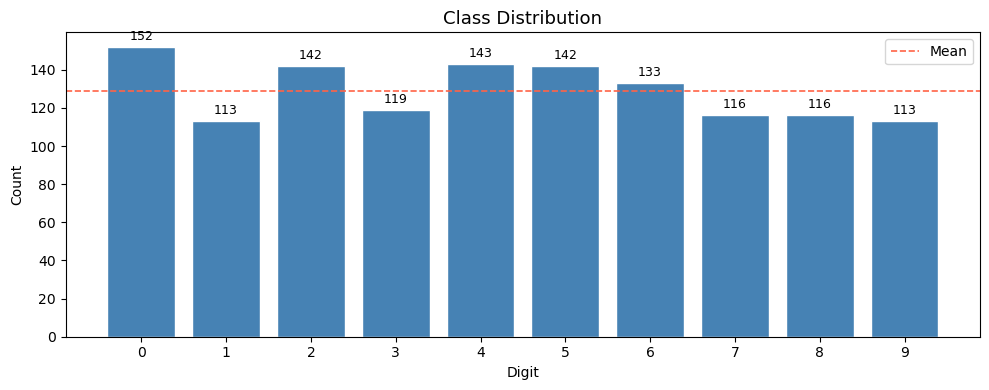

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(), color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.axhline(total / NUM_CLASSES, color="tomato", linestyle="--", linewidth=1.2, label="Mean")
ax.set_title("Class Distribution", fontsize=13)
ax.set_xlabel("Digit")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## PHASE 3 — Image Preprocessing

Pipeline per image:
1. Convert to grayscale
2. Gaussian blur (radius 1) — removes sensor noise
3. Otsu binarisation — adaptive threshold, invariant to lighting
4. Invert if background is dark (ensure white digit on black background)
5. MaxFilter dilation — thickens thin strokes for consistency
6. Resize to `IMG_SIZE × IMG_SIZE` with Lanczos anti-aliasing
7. Normalise to [0, 1]

In [40]:
def otsu_threshold(img_array: np.ndarray) -> int:
    """Compute Otsu's optimal binarisation threshold (pure-NumPy)."""
    hist = np.bincount(img_array.astype(np.uint8).ravel(), minlength=256)
    total = img_array.size
    sum_total = float(np.dot(np.arange(256), hist))
    sum_bg, w_bg, best_var, thresh = 0.0, 0, 0.0, 0
    for t in range(256):
        w_bg += hist[t]
        if w_bg == 0:
            continue
        w_fg = total - w_bg
        if w_fg == 0:
            break
        sum_bg += t * hist[t]
        mean_diff = sum_bg / w_bg - (sum_total - sum_bg) / w_fg
        var = w_bg * w_fg * mean_diff * mean_diff
        if var > best_var:
            best_var, thresh = var, t
    return thresh


def preprocess_image(img_path: str) -> np.ndarray:
    """Return a (IMG_SIZE, IMG_SIZE) float32 array in [0, 1]."""
    img = Image.open(img_path).convert("L")
    img = img.filter(ImageFilter.GaussianBlur(radius=1))
    arr = np.array(img)

    # Otsu binarisation
    thresh = otsu_threshold(arr)
    arr = np.where(arr > thresh, 255, 0).astype(np.uint8)

    # Ensure white digit on black background
    if arr.mean() > 128:
        arr = 255 - arr

    # Morphological dilation — thickens strokes (3×3 MaxFilter)
    img = Image.fromarray(arr)
    img = img.filter(ImageFilter.MaxFilter(size=3))

    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    return np.array(img, dtype=np.float32) / 255.0


# ── Sanity check ─────────────────────────────────────────────────────────────
sample_dir = os.path.join(DATASET_DIR, "0")
sample_path = os.path.join(sample_dir, os.listdir(sample_dir)[0])
sample = preprocess_image(sample_path)
print(f"Output shape : {sample.shape}, range : [{sample.min():.2f}, {sample.max():.2f}]")

Output shape : (32, 32), range : [0.00, 1.00]


In [41]:
images, labels = [], []

for digit in sorted(os.listdir(DATASET_DIR)):
    folder = os.path.join(DATASET_DIR, digit)
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if not fname.lower().endswith(IMG_EXTS):
            continue
        try:
            images.append(preprocess_image(os.path.join(folder, fname)))
            labels.append(int(digit))
        except Exception as exc:
            print(f"  [SKIP] {fname}: {exc}")

# Shape: (N, H, W, 1)
images = np.expand_dims(np.array(images, dtype=np.float32), axis=-1)
labels = np.array(labels, dtype=np.int32)
print(f"Loaded — images: {images.shape}, labels: {labels.shape}")

Loaded — images: (1289, 32, 32, 1), labels: (1289,)


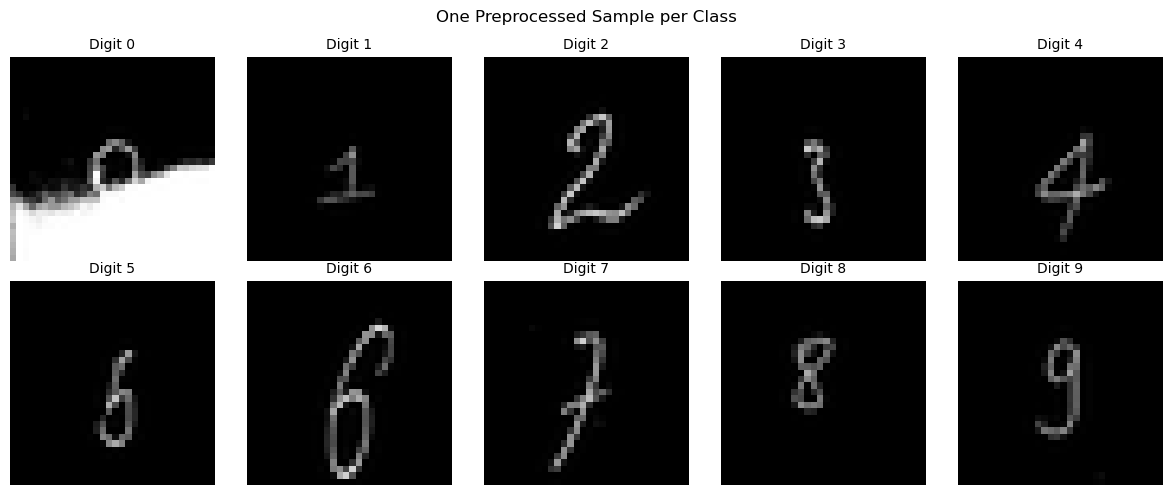

In [42]:
# Show one preprocessed sample per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(NUM_CLASSES):
    idx = np.where(labels == i)[0][0]
    row, col = divmod(i, 5)
    axes[row, col].imshow(images[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[row, col].set_title(f"Digit {i}", fontsize=10)
    axes[row, col].axis("off")
plt.suptitle("One Preprocessed Sample per Class", fontsize=12)
plt.tight_layout()
plt.show()

## PHASE 4 — Dataset Splitting

Split: **60 % train / 20 % validation / 20 % test** (stratified).

In [43]:
X_tv, X_test, y_tv, y_test = train_test_split(
    images, labels, test_size=0.20, random_state=SEED, stratify=labels)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=SEED, stratify=y_tv)

print(f"Train : {X_train.shape[0]}")
print(f"Val   : {X_val.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

Train : 773
Val   : 258
Test  : 258


## PHASE 5 — Data Augmentation

Applied **only at training time** (inside `tf.data` so it runs on GPU/CPU in parallel):
- Small rotation (±15°)
- Small translation (±8 %)
- Small zoom (±8 %)
- Random contrast jitter — simulates varying ink density

In [44]:
augment_layer = keras.Sequential([
    layers.RandomRotation(factor=0.08, fill_mode="constant", fill_value=0.0),
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08,
                             fill_mode="constant", fill_value=0.0),
    layers.RandomZoom(height_factor=0.08, fill_mode="constant", fill_value=0.0),
    layers.RandomContrast(factor=0.15),
], name="augmentation")


def make_dataset(X, y, augment: bool = False, shuffle: bool = False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(
            lambda x, lbl: (augment_layer(x, training=True), lbl),
            num_parallel_calls=tf.data.AUTOTUNE,
        )
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(X_train, y_train, augment=True, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

print("Datasets ready.")

Datasets ready.


## PHASE 6 — CNN Model

Architecture changes vs. previous version:
- **Block 4** uses `SeparableConv2D` — same receptive field, ~8× fewer parameters
- `L2` weight decay on Dense layers — counters over-fitting on the small dataset
- `GlobalAveragePooling2D` replaces `Flatten` — spatial invariance, smaller head

In [45]:
def build_cnn(
    input_shape: tuple = (IMG_SIZE, IMG_SIZE, 1),
    num_classes: int   = NUM_CLASSES,
    l2: float          = 1e-4,
) -> keras.Model:
    """Small but deep CNN tuned for the ~1 k-image digit dataset."""

    reg = regularizers.l2(l2)

    def conv_bn_relu(filters, kernel=3):
        return [
            layers.Conv2D(filters, kernel, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
        ]

    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # ── Block 1 : 32 × 32 → 16 × 16 ─────────────────────────────────────
        *conv_bn_relu(32),
        *conv_bn_relu(32),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        # ── Block 2 : 16 × 16 → 8 × 8 ───────────────────────────────────────
        *conv_bn_relu(64),
        *conv_bn_relu(64),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Block 3 : 8 × 8 → 4 × 4 ─────────────────────────────────────────
        *conv_bn_relu(128),
        *conv_bn_relu(128),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        # ── Block 4 : 4 × 4 → 2 × 2  (SeparableConv — fewer params) ─────────
        layers.SeparableConv2D(256, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        # ── Classification head ───────────────────────────────────────────────
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.40),
        layers.Dense(128, kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax"),
    ], name="digit_cnn")

    return model


model = build_cnn()
model.summary(line_length=80)

Model: "digit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                │ (None, 32, 32, 32)       │           288 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_18            │ (None, 32, 32, 32)       │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_18 (Activation)        │ (None, 32, 32, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)                │ (None, 32, 32, 32)       │         9,216 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_19            │ (None, 32, 32, 32)       │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_19 (Activation)        │ (None, 32, 32, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)    │ (None, 16, 16, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_12 (Dropout)              │ (None, 16, 16, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)                │ (None, 16, 16, 64)       │        18,432 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_20            │ (None, 16, 16, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_20 (Activation)        │ (None, 16, 16, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)                │ (None, 16, 16, 64)       │        36,864 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_21            │ (None, 16, 16, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_21 (Activation)        │ (None, 16, 16, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)    │ (None, 8, 8, 64)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_13 (Dropout)              │ (None, 8, 8, 64)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)                │ (None, 8, 8, 128)        │        73,728 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_22            │ (None, 8, 8, 128)        │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_22 (Activation)        │ (None, 8, 8, 128)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)                │ (None, 8, 8, 128)        │       147,456 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_23            │ (None, 8, 8, 128)        │           512 │
│ (BatchNormalization)         

 Total params: 424,234 (1.62 MB)

 Trainable params: 422,058 (1.61 MB)

 Non-trainable params: 2,176 (8.50 KB)

## PHASE 7 — Compile & Train

- **Loss**: sparse categorical cross-entropy with label smoothing 0.1 — prevents over-confident predictions
- **LR schedule**: Cosine Decay with warm restarts — escapes local minima better than step decay
- **ModelCheckpoint**: saves only when `val_accuracy` improves

In [ ]:
# ── Learning-rate schedule ────────────────────────────────────────────────────
# One "cycle" = 20 epochs; LR restarts twice (T_mul=2) with decreasing amplitude
steps_per_epoch = len(X_train) // BATCH_SIZE + 1
lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate = LR_INIT,
    first_decay_steps     = 20 * steps_per_epoch,
    t_mul                 = 2.0,
    m_mul                 = 0.8,   # each restart starts at 80 % of previous peak
    alpha                 = 1e-6,  # minimum LR
)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule),
    loss      = keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor           = "val_accuracy",
        patience          = 25,
        restore_best_weights = True,
        verbose           = 1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath          = "best_digit_cnn.keras",
        monitor           = "val_accuracy",
        save_best_only    = True,
        verbose           = 0,
    ),
]

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1,
)

print(f"\nTraining finished after {len(history.history['loss'])} epochs.")
print(f"Best val accuracy : {max(history.history['val_accuracy']):.4f}")

Epoch 1/100


C:\Users\ISUG\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.0996 - loss: 2.8225 - val_accuracy: 0.0853 - val_loss: 2.3546
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.1281 - loss: 2.5869 - val_accuracy: 0.0853 - val_loss: 2.3567
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1630 - loss: 2.5072 - val_accuracy: 0.0853 - val_loss: 2.3960
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1514 - loss: 2.4701 - val_accuracy: 0.1124 - val_loss: 2.4399
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.1539 - loss: 2.4616 - val_accuracy: 0.1124 - val_loss: 2.4730
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1721 - loss: 2.4075 - val_accuracy: 0.0930 - val_loss: 2.4727
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.1643 - loss: 2.3908 - val_accuracy: 0.1124 - val_loss: 2.4672
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1759 - loss: 2.3518 - val_accuracy: 0.0891 - val_l

## PHASE 8 — Evaluation

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
ep = range(1, len(history.history["accuracy"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep, history.history["accuracy"],     "b-",  label="Train")
ax1.plot(ep, history.history["val_accuracy"], "r--", label="Val")
ax1.set_title("Accuracy");  ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history.history["loss"],     "b-",  label="Train")
ax2.plot(ep, history.history["val_loss"], "r--", label="Val")
ax2.set_title("Loss");  ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("Training History", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Headline metrics ──────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test loss     : {test_loss:.4f}")
print(f"Best val acc  : {max(history.history['val_accuracy']):.4f}")

In [ ]:
# ── Per-class report ──────────────────────────────────────────────────────────
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, digits=4))

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ── Misclassified samples (up to 20) ─────────────────────────────────────────
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(y_test)}")

show = wrong_idx[:20]
if len(show) > 0:
    ncols = min(len(show), 5)
    nrows = (len(show) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.8 * nrows))
    axes = np.array(axes).flatten()
    for ax, idx in zip(axes, show):
        ax.imshow(X_test[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"True {y_test[idx]}\nPred {y_pred[idx]}", fontsize=8, color="red")
        ax.axis("off")
    for ax in axes[len(show):]:
        ax.axis("off")
    plt.suptitle("Misclassified Samples", fontsize=12)
    plt.tight_layout()
    plt.show()

## PHASE 9 — Interactive Prediction Widget

Upload any handwritten digit image and the model will predict it instantly.

In [ ]:
from IPython.display import display, clear_output
import ipywidgets as widgets
import io


def preprocess_pil(pil_img):
    pil_img = pil_img.convert("L")
    pil_img = pil_img.filter(ImageFilter.GaussianBlur(radius=1))
    arr = np.array(pil_img)
    thresh = otsu_threshold(arr)
    arr = np.where(arr > thresh, 255, 0).astype(np.uint8)
    if arr.mean() > 128:
        arr = 255 - arr
    pil_img = Image.fromarray(arr).filter(ImageFilter.MaxFilter(size=3))
    pil_img = pil_img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    return np.expand_dims(
        np.array(pil_img, dtype=np.float32) / 255.0, axis=(0, -1)
    )


def run_inference(pil_img, filename=""):
    proc  = preprocess_pil(pil_img)
    probs = model.predict(proc, verbose=0)[0]
    pred  = int(np.argmax(probs))
    conf  = float(probs[pred]) * 100

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(pil_img, cmap="gray")
    title = "Original" + (": " + filename if filename else "")
    axes[0].set_title(title, fontsize=10)
    axes[0].axis("off")
    axes[1].imshow(proc[0].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("After Preprocessing", fontsize=10)
    axes[1].axis("off")
    colors = ["#2ecc71" if i == pred else "steelblue" for i in range(10)]
    axes[2].barh(range(10), probs, color=colors)
    axes[2].set_yticks(range(10))
    axes[2].set_xlabel("Probability")
    axes[2].set_title("Class Probabilities", fontsize=10)
    axes[2].set_xlim(0, 1)
    plt.suptitle("Prediction: {}   ({:.1f}% confidence)".format(pred, conf),
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 42)
    print("  PREDICTED DIGIT : {}".format(pred))
    print("  CONFIDENCE      : {:.1f}%".format(conf))
    print("=" * 42)
    for i, p in enumerate(probs):
        bar    = "#" * int(p * 30)
        marker = " <- predicted" if i == pred else ""
        print("  {}: {:5.1f}%  {}{}".format(i, p * 100, bar, marker))


# ── Widget ────────────────────────────────────────────────────────────────────
out = widgets.Output()

upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload image",
    style={"description_width": "initial"},
)


def _on_upload(change):
    uploaded = change["new"]
    # ipywidgets 8 returns a tuple of dicts; skip if empty
    if not uploaded:
        return
    if isinstance(uploaded, (list, tuple)):
        entry    = uploaded[0]
        filename = entry.get("name", "uploaded")
        raw      = entry["content"]
    else:
        filename = next(iter(uploaded))
        raw      = uploaded[filename]["content"]
    content = bytes(raw) if not isinstance(raw, (bytes, bytearray)) else raw
    with out:
        clear_output(wait=True)
        print("File received: {}  ({:,} bytes)".format(filename, len(content)))
        pil_img = Image.open(io.BytesIO(content))
        run_inference(pil_img, filename)


upload_widget.observe(_on_upload, names="value")
display(upload_widget, out)
print("Upload a handwritten digit image — prediction runs automatically.")


In [ ]:
# ── Quick CLI test (uses a known image from the dataset) ─────────────────────
sample_dir2 = os.path.join(DATASET_DIR, "5")
quick_path  = os.path.join(sample_dir2, os.listdir(sample_dir2)[0])
print(f"Quick-testing with: {quick_path}")
run_inference(Image.open(quick_path), os.path.basename(quick_path))

## PHASE 10 — Save & Deploy

In [ ]:
MODEL_PATH = "handwritten_digit_cnn.keras"
model.save(MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")

# Verify round-trip
loaded = keras.models.load_model(MODEL_PATH)
_, loaded_acc = loaded.evaluate(test_ds, verbose=0)
print(f"Reloaded test accuracy: {loaded_acc:.4f}")

In [ ]:
%%writefile app.py
"""Streamlit web app for handwritten digit recognition."""
import io
import numpy as np
import streamlit as st
from PIL import Image, ImageFilter
import tensorflow as tf

st.set_page_config(
    page_title="Digit Recogniser",
    page_icon="🔢",
    layout="centered",
)

IMG_SIZE = 32


@st.cache_resource
def load_model():
    return tf.keras.models.load_model("handwritten_digit_cnn.keras")


def otsu_threshold(arr: np.ndarray) -> int:
    hist = np.bincount(arr.astype(np.uint8).ravel(), minlength=256)
    total = arr.size
    s_tot = float(np.dot(np.arange(256), hist))
    s_bg, w_bg, best, t_best = 0.0, 0, 0.0, 0
    for t in range(256):
        w_bg += hist[t]
        if w_bg == 0:
            continue
        w_fg = total - w_bg
        if w_fg == 0:
            break
        s_bg += t * hist[t]
        d = s_bg / w_bg - (s_tot - s_bg) / w_fg
        v = w_bg * w_fg * d * d
        if v > best:
            best, t_best = v, t
    return t_best


def preprocess(pil_img: Image.Image) -> np.ndarray:
    pil_img = pil_img.convert("L").filter(ImageFilter.GaussianBlur(radius=1))
    arr = np.array(pil_img)
    arr = np.where(arr > otsu_threshold(arr), 255, 0).astype(np.uint8)
    if arr.mean() > 128:
        arr = 255 - arr
    pil_img = Image.fromarray(arr).filter(ImageFilter.MaxFilter(size=3))
    pil_img = pil_img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    return np.expand_dims(
        np.array(pil_img, dtype=np.float32) / 255.0, axis=(0, -1)
    )


model = load_model()

st.title("🔢 Handwritten Digit Recognition")
st.write("Upload a photo of a handwritten digit (0 – 9).")

uploaded = st.file_uploader("Choose image…", type=["jpg", "jpeg", "png", "bmp"])

if uploaded:
    pil_img = Image.open(io.BytesIO(uploaded.read()))
    col1, col2 = st.columns(2)
    with col1:
        st.image(pil_img, caption="Uploaded image", use_column_width=True)
    with col2:
        proc = preprocess(pil_img)
        st.image(
            (proc[0].squeeze() * 255).astype(np.uint8),
            caption="After preprocessing",
            use_column_width=True,
        )

    probs  = model.predict(proc, verbose=0)[0]
    digit  = int(np.argmax(probs))
    conf   = float(probs[digit]) * 100

    st.success(f"**Predicted digit: {digit}** — {conf:.1f}% confidence")

    st.subheader("All class probabilities")
    for i, p in enumerate(probs):
        label = f"Digit {i}  {'✅' if i == digit else ''}"
        st.progress(float(p), text=f"{label}: {p*100:.1f}%")

In [ ]:
print("To launch the web app run:")
print("    streamlit run app.py")